In [130]:
# Autoload modules
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [131]:
import sys
sys.path.append('..')
from fcc import MiyazawaJerniganInteraction, Peptide, ProteinFoldingProblem, PenaltyParameters, ProteinFoldingResult
from vqe import VQEC, VQECOpt
from qiskit.circuit.library import RealAmplitudes
from qiskit.primitives import Sampler, Estimator
from qiskit_algorithms.gradients import ParamShiftEstimatorGradient, LinCombEstimatorGradient
import numpy as np
import matplotlib.pyplot as plt

In [132]:
def build_pf(main_seq: str, energy_matrix_file: str = "mj_matrix"):
    """Builds the protein folding problem for the given sequence."""

    mj_interaction = MiyazawaJerniganInteraction(energy_matrix_file)
    print(mj_interaction.calculate_energy_matrix(main_seq))

    penalty_back = 50
    penalty_redun = 50
    # penalty_olap = 50

    penalty_terms = PenaltyParameters(penalty_back, penalty_redun)

    peptide = Peptide(main_seq)

    protein_folding_problem = ProteinFoldingProblem(peptide, mj_interaction, penalty_terms)

    return protein_folding_problem

In [133]:

main_seq_4 = "IFGA" # 6MVZ ("LFLF")YYDPETGTWY
protein_folding_problem = build_pf(main_seq_4)
qubit_op = protein_folding_problem.qubit_op()
print(f"Number of qubits: {qubit_op.num_qubits}")
print(f"Number of terms: {len(qubit_op)}")

[[ 0.   -6.84 -3.78 -4.58]
 [ 0.    0.   -4.13 -4.81]
 [ 0.    0.    0.   -2.31]
 [ 0.    0.    0.    0.  ]]
Number of qubits: 9
Number of terms: 107


In [134]:
bead_pairs, olap_constr_ops = protein_folding_problem.olap_constr_ops()
print(f"Number of overlap constraints: {len(olap_constr_ops)}")
print(f"Number of qubits: {olap_constr_ops[0].num_qubits}")

Number of overlap constraints: 1
Number of qubits: 9


Converged after 52 iterations
Converged after 79 iterations
Converged after 87 iterations
Converged after 76 iterations
Mean Relative Errors per Iteration: [3.39589107 2.42994017 1.98429017 1.75495244 1.59261697 1.43639152
 1.30919541 1.24680554 1.17869223 1.11159371 1.05017985 0.99636549
 0.97351561 0.96683398 0.96081974 0.95344093 0.94336396 0.92973752
 0.91205793 0.89037341 0.86577499 0.8403262  0.81644991 0.79580581
 0.78504929 0.78240864 0.77796319 0.77264987 0.76667293 0.75957819
 0.75071251 0.73980919 0.74563586 0.76255494 0.7787907  0.79319535
 0.80517523 0.81482556 0.82264305 0.82914481 0.83469265 0.83949223
 0.84364721 0.84720791 0.85020242 0.8526541  0.85459005 0.85604409
 0.8570564  0.85767155 0.85793593 0.85789546 0.85759374 0.88018264
 0.879372   0.87838607 0.87725455 0.87599819 0.87461948 0.87307131
 0.87113811 0.86790203 0.85921349 0.82952945 0.77511595 0.84438061
 0.87991473 0.89229549 0.89499495 0.893778   0.88936034 0.87902759
 0.85378207 0.81636484 0.75653124 0.8045

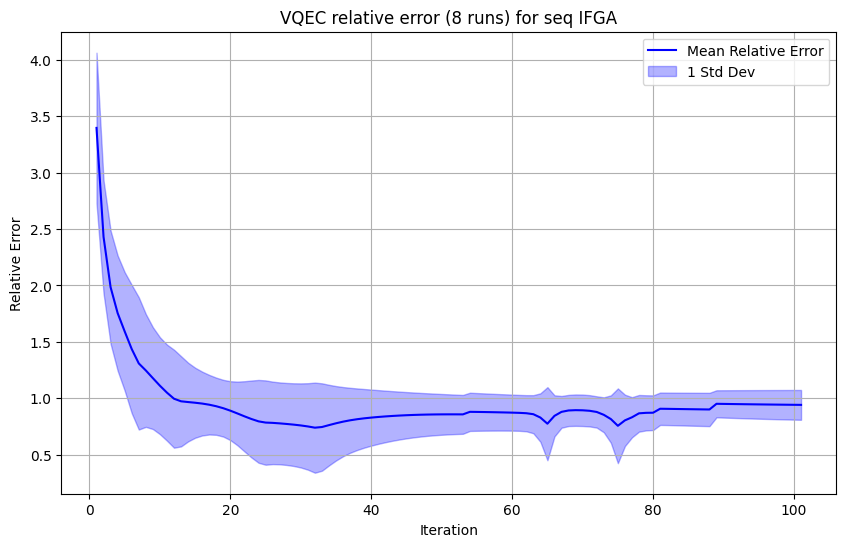

In [135]:
n_runs = 8
max_iter = 100
true_optimal_value = -13.170000
vqec_energies = []
for i in range(n_runs): 
    cost_errors = []
    ansatz = RealAmplitudes(qubit_op.num_qubits, reps=1)
    estimator = Estimator()
    gradient = LinCombEstimatorGradient(estimator=estimator)
    vqec = VQECOpt(qubit_op=qubit_op, constr_ops=olap_constr_ops, ansatz=ansatz, estimator=estimator, gradient=gradient, max_iter=100)
    vqec_result = vqec.optimize_primal_dual()
    if len(vqec_result.energies) < max_iter + 1:
        vqec_result.energies = np.pad(vqec_result.energies, (0, max_iter+1 - len(vqec_result.energies)), 
                             'constant', constant_values=np.nan)
    assert len(vqec_result.energies) == max_iter+1, "Array length is not equal to max_iter after padding"  
    vqec_energies.append(vqec_result.energies)

    
vqec_energies = np.array(vqec_energies)
relative_errors = np.abs(vqec_energies - true_optimal_value) / np.abs(true_optimal_value)

# mean and standard deviation of the relative errors across runs
mean_relative_errors = np.nanmean(relative_errors, axis=0)
std_relative_errors = np.nanstd(relative_errors, axis=0)

# print("Mean Relative Errors per Iteration:", mean_relative_errors)
# print("Standard Deviation of Relative Errors per Iteration:", std_relative_errors)

num_iterations = vqec_energies.shape[1]
iterations = np.arange(1, num_iterations + 1)

# Plotting the mean relative error with confidence intervals
plt.figure(figsize=(10, 6))
plt.plot(iterations, mean_relative_errors, label='Mean Relative Error', color='blue')
plt.fill_between(iterations, mean_relative_errors - std_relative_errors, 
                 mean_relative_errors + std_relative_errors, color='blue', alpha=0.3, label='1 Std Dev')

plt.xlabel('Iteration')
plt.ylabel('Relative Error')
plt.title('VQEC relative error (8 runs) for seq ' + main_seq_4 )
plt.legend()
plt.grid(True)
plt.show()



In [136]:
full_circ = vqec_result.ansatz.copy()
full_circ.measure_all()
sampler = Sampler(options={"shots": 10000})
sampler_result = sampler.run(circuits=[full_circ], parameter_values=vqec_result.optimal_primal_vars).result()
quasi_dist = sampler_result.quasi_dists[0].binary_probabilities()

# Sort the binary strings by their probabilities
sorted_quasi_dist = dict(sorted(quasi_dist.items(), key=lambda item: item[1], reverse=True))
# Compute the energies of all samples
from qufold.execution_utils.measurements import _evaluate_sparsepauli
bitstring_energies = {}
for i, (sample, prob) in enumerate(sorted_quasi_dist.items()):
    if i >= 5:
        break
    energy = _evaluate_sparsepauli(sample, qubit_op)
    bitstring_energies[sample] = energy
    print(f"Sample {i}: {sample} with probability {prob} and energy {energy}")

Sample 0: 111011010 with probability 0.9997 and energy -22.330000000000002
Sample 1: 110011010 with probability 0.0003 and energy -18.55


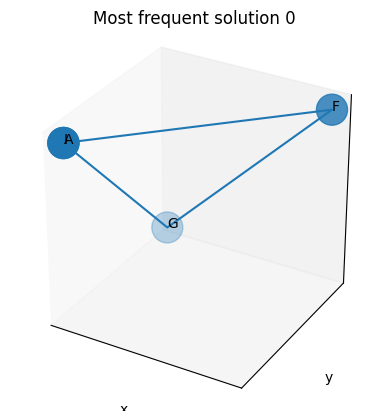

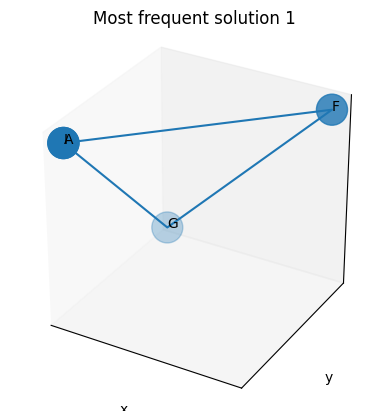

In [137]:
for i, (sample, energy) in enumerate(bitstring_energies.items()):
    pf_result = ProteinFoldingResult(peptide=protein_folding_problem.peptide, unused_qubits=protein_folding_problem.unused_qubits, solution_bitstring=sample)
    fig = pf_result.get_figure(title=f"Most frequent solution {i}")
    plt.show()